## NLP text prepreocessing 

In this notebook, I'll walk through how I processed a Reddit dataset pulled using the RedditExtractoR library in R.

To get the data ready for the model, I used several NLP techniques like POS tagging and NER to clean and structure the text. For the final step, I used FinBERT to calculate sentiment scores. Since FinBERT is trained specifically for finance, it’s much better at picking up on market-related tone than a standard sentiment tool.

#### Import libraries

In [1]:
import numpy as np
import torch
import pandas as pd
import os
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
import spacy
from spacy import displacy
from spacy import tokenizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, LdaModel, TfidfModel
seed=42

In [2]:
# set plot options
plt.rcParams['figure.figsize'] = (12, 8)
default_plot_colour = "#00bfbf"

In [3]:
#Read the data from the datasets directory
data_news = pd.read_csv('../datasets/reddit_market_tech_final.csv')

In [4]:
data_news

,date_utc,title,url,category_tag,subreddit
0,2026-01-24,Intel didn't crash because of earnings - it cr...,https://www.reddit.com/r/stocks/comments/1qldh...,Macro_Bear,stocks
1,2026-01-22,Fed's main gauge shows inflation at 2.8% in No...,https://www.reddit.com/r/finance/comments/1qk0...,Economy,finance
2,2026-01-21,AMZN vs. GOOGL vs. MSFT vs. NVDA,https://www.reddit.com/r/stocks/comments/1qj1o...,Google,stocks
3,2026-01-21,Energy costs will decide which countries win t...,https://www.reddit.com/r/stocks/comments/1qj0z...,Microsoft,stocks
4,2026-01-20,Barcelona train crash latest: Train driver dea...,https://www.reddit.com/r/news/comments/1qifh4r...,Macro_Bear,news
...,...,...,...,...,...
2267,2010-05-10,Correlation Math Signals Bull Market; Oil\r\nS...,https://www.reddit.com/r/finance/comments/c23o...,Macro_Bull,finance
2268,2009-10-10,T-Mobile Sidekick Disaster: Microsoft and T-Mo...,https://www.reddit.com/r/news/comments/9styq/t...,Microsoft,news
2269,2009-06-25,What inflation ? Rates fall as Fed sells $25B...,https://www.reddit.com/r/finance/comments/8vph...,Economy,finance
2270,2009-06-04,The Gold Bull Market and the Fed it Rode In On,https://www.reddit.com/r/finance/comments/8pvd...,Macro_Bull,finance


In [5]:
#Let's have a look at the category types
data_news['category_tag'].unique()

array(['Macro_Bear', 'Economy', 'Google', 'Microsoft', 'Macro_Bull',
       'Berkshire', 'SPY_SNP', 'JNJ', 'PG'], dtype=object)

In [6]:
#I will let all the categories because all are relevant for S&P 500 index
relevant_categories = ['Macro_Bear', 'Economy', 'Google', 'Microsoft', 'Macro_Bull',
       'Berkshire', 'SPY_SNP', 'JNJ', 'PG']

In [7]:
data_fin = data_news[data_news['category_tag'].isin(relevant_categories)].copy()

In [8]:
#Convert the date column to datetime
data_fin['date'] = pd.to_datetime(data_fin['date_utc'], errors='coerce')

In [9]:
data_fin = data_fin.drop(['date_utc'], axis=1)

In [10]:
#Let's have a look at the dataset
data_fin.head()

,title,url,category_tag,subreddit,date
0,Intel didn't crash because of earnings - it cr...,https://www.reddit.com/r/stocks/comments/1qldh...,Macro_Bear,stocks,2026-01-24
1,Fed's main gauge shows inflation at 2.8% in No...,https://www.reddit.com/r/finance/comments/1qk0...,Economy,finance,2026-01-22
2,AMZN vs. GOOGL vs. MSFT vs. NVDA,https://www.reddit.com/r/stocks/comments/1qj1o...,Google,stocks,2026-01-21
3,Energy costs will decide which countries win t...,https://www.reddit.com/r/stocks/comments/1qj0z...,Microsoft,stocks,2026-01-21
4,Barcelona train crash latest: Train driver dea...,https://www.reddit.com/r/news/comments/1qifh4r...,Macro_Bear,news,2026-01-20


In [11]:
data_fin.columns

Index(['title', 'url', 'category_tag', 'subreddit', 'date'], dtype='object')

In [12]:
#Final datset will contain only date and title of the news
data_final = data_fin[['date','title']]

In [13]:
data_final.head(10)

,date,title
0,2026-01-24,Intel didn't crash because of earnings - it cr...
1,2026-01-22,Fed's main gauge shows inflation at 2.8% in No...
2,2026-01-21,AMZN vs. GOOGL vs. MSFT vs. NVDA
3,2026-01-21,Energy costs will decide which countries win t...
4,2026-01-20,Barcelona train crash latest: Train driver dea...
5,2026-01-17,Space Stocks Pullback Imminent? Or Continued B...
6,2026-01-16,OpenAI implementing ads in ChatGPT- Finally ti...
7,2026-01-15,Are we adding to positions in google
8,2026-01-15,"Wikipedia inks AI deals with Microsoft, Meta a..."
9,2026-01-14,"How do one predict, the next metal market cras..."


In [14]:
data_final['date'].min()

Timestamp('2009-05-09 00:00:00')

In [15]:
data_final['date'].max()

Timestamp('2026-01-24 00:00:00')

In [16]:
#Let's sort the dataset by date in ascending order
data_final = data_final.sort_values(by='date', ascending=True).reset_index(drop=True)

In [17]:
data_final.head(10)

,date,title
0,2009-05-09,SP500 Elliott Wave Update: Competiting Interpr...
1,2009-06-04,The Gold Bull Market and the Fed it Rode In On
2,2009-06-25,What inflation ? Rates fall as Fed sells $25B...
3,2009-10-10,T-Mobile Sidekick Disaster: Microsoft and T-Mo...
4,2010-05-10,Correlation Math Signals Bull Market; Oil\r\nS...
5,2010-06-07,Who thought studying finance could be fraught ...
6,2010-07-04,Iceland holds talks with UK and Netherlands on...
7,2010-07-04,India raises interest rates to curb inflation ...
8,2010-08-04,Thirty-eight US billionaires have pledged at l...
9,2010-08-31,Herpaderp. Need help reading google finance.


We can see that on some days there are multiple news items; for example, on 2010-07-04, there were two. To ensure that each date appears only once, I will first count the number of news items per day and then concatenate the first five for each date.

In [18]:
#I will create a variable to count how many news are on each day
news_daily = (
    data_final
    .groupby(data_final['date'].dt.date)
    .size()
    .reset_index(name="news_count")
)

news_daily["date"] = pd.to_datetime(news_daily["date"])

In [23]:
news_daily.head()

,date,news_count
0,2009-05-09,1
1,2009-06-04,1
2,2009-06-25,1
3,2009-10-10,1
4,2010-05-10,1


In [19]:
news_daily['news_count'].max()

np.int64(6)

In [20]:
#Created a function to select the first 6 news for each day
N = 6

def first_five(s, n=6):
    s = s.dropna().astype(str).str.strip()
    s = s[s != ""]                      
    return " | ".join(s.head(n))

all_news = (
    data_final.sort_values("date")
    .groupby(data_final["date"].dt.normalize())["title"]  
    .apply(lambda s: first_five(s, N))
    .reset_index(name="news")
)

all_news.head()


,date,news
0,2009-05-09,SP500 Elliott Wave Update: Competiting Interpr...
1,2009-06-04,The Gold Bull Market and the Fed it Rode In On
2,2009-06-25,What inflation ? Rates fall as Fed sells $25B...
3,2009-10-10,T-Mobile Sidekick Disaster: Microsoft and T-Mo...
4,2010-05-10,Correlation Math Signals Bull Market; Oil\r\nS...


In [21]:
all_news['news'][:1]

0    SP500 Elliott Wave Update: Competiting Interpr...
Name: news, dtype: object

## Text Pre-processing

In [22]:
news_prep = all_news.copy()

In [23]:
#1.Lowercase

news_prep['clean'] = news_prep['news'].str.lower()

news_prep

,date,news,clean
0,2009-05-09,SP500 Elliott Wave Update: Competiting Interpr...,sp500 elliott wave update: competiting interpr...
1,2009-06-04,The Gold Bull Market and the Fed it Rode In On,the gold bull market and the fed it rode in on
2,2009-06-25,What inflation ? Rates fall as Fed sells $25B...,what inflation ? rates fall as fed sells $25b...
3,2009-10-10,T-Mobile Sidekick Disaster: Microsoft and T-Mo...,t-mobile sidekick disaster: microsoft and t-mo...
4,2010-05-10,Correlation Math Signals Bull Market; Oil\r\nS...,correlation math signals bull market; oil\r\ns...
...,...,...,...
1639,2026-01-17,Space Stocks Pullback Imminent? Or Continued B...,space stocks pullback imminent? or continued b...
1640,2026-01-20,Barcelona train crash latest: Train driver dea...,barcelona train crash latest: train driver dea...
1641,2026-01-21,Energy costs will decide which countries win t...,energy costs will decide which countries win t...
1642,2026-01-22,Fed's main gauge shows inflation at 2.8% in No...,fed's main gauge shows inflation at 2.8% in no...


In [24]:
#2.Remove punctuation

news_prep['clean'] = news_prep.apply(lambda x: re.sub(r"([^\w\s])", "", x['clean']), axis=1)

news_prep.head()

,date,news,clean
0,2009-05-09,SP500 Elliott Wave Update: Competiting Interpr...,sp500 elliott wave update competiting interpre...
1,2009-06-04,The Gold Bull Market and the Fed it Rode In On,the gold bull market and the fed it rode in on
2,2009-06-25,What inflation ? Rates fall as Fed sells $25B...,what inflation rates fall as fed sells 25b i...
3,2009-10-10,T-Mobile Sidekick Disaster: Microsoft and T-Mo...,tmobile sidekick disaster microsoft and tmobil...
4,2010-05-10,Correlation Math Signals Bull Market; Oil\r\nS...,correlation math signals bull market oil\r\nst...


In [25]:
#3.Remove stopwords

en_stopwords = stopwords.words('english')
en_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [26]:
news_prep['no_stopwords'] = news_prep['clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in (en_stopwords)]))

news_prep.head()

,date,news,clean,no_stopwords
0,2009-05-09,SP500 Elliott Wave Update: Competiting Interpr...,sp500 elliott wave update competiting interpre...,sp500 elliott wave update competiting interpre...
1,2009-06-04,The Gold Bull Market and the Fed it Rode In On,the gold bull market and the fed it rode in on,gold bull market fed rode
2,2009-06-25,What inflation ? Rates fall as Fed sells $25B...,what inflation rates fall as fed sells 25b i...,inflation rates fall fed sells 25b bonds
3,2009-10-10,T-Mobile Sidekick Disaster: Microsoft and T-Mo...,tmobile sidekick disaster microsoft and tmobil...,tmobile sidekick disaster microsoft tmobile lo...
4,2010-05-10,Correlation Math Signals Bull Market; Oil\r\nS...,correlation math signals bull market oil\r\nst...,correlation math signals bull market oil stock...


In [27]:
#4.Tokenization

news_prep['tokens'] =news_prep.apply(lambda x: word_tokenize(x['no_stopwords']), axis=1)

news_prep.head()

,date,news,clean,no_stopwords,tokens
0,2009-05-09,SP500 Elliott Wave Update: Competiting Interpr...,sp500 elliott wave update competiting interpre...,sp500 elliott wave update competiting interpre...,"[sp500, elliott, wave, update, competiting, in..."
1,2009-06-04,The Gold Bull Market and the Fed it Rode In On,the gold bull market and the fed it rode in on,gold bull market fed rode,"[gold, bull, market, fed, rode]"
2,2009-06-25,What inflation ? Rates fall as Fed sells $25B...,what inflation rates fall as fed sells 25b i...,inflation rates fall fed sells 25b bonds,"[inflation, rates, fall, fed, sells, 25b, bonds]"
3,2009-10-10,T-Mobile Sidekick Disaster: Microsoft and T-Mo...,tmobile sidekick disaster microsoft and tmobil...,tmobile sidekick disaster microsoft tmobile lo...,"[tmobile, sidekick, disaster, microsoft, tmobi..."
4,2010-05-10,Correlation Math Signals Bull Market; Oil\r\nS...,correlation math signals bull market oil\r\nst...,correlation math signals bull market oil stock...,"[correlation, math, signals, bull, market, oil..."


In [28]:
#5.Lemmatization

lemmatizer = WordNetLemmatizer()

news_prep['lemmatize'] = news_prep['tokens'].apply(lambda x: [lemmatizer.lemmatize(tokens) for tokens in x])

news_prep.head()

,date,news,clean,no_stopwords,tokens,lemmatize
0,2009-05-09,SP500 Elliott Wave Update: Competiting Interpr...,sp500 elliott wave update competiting interpre...,sp500 elliott wave update competiting interpre...,"[sp500, elliott, wave, update, competiting, in...","[sp500, elliott, wave, update, competiting, in..."
1,2009-06-04,The Gold Bull Market and the Fed it Rode In On,the gold bull market and the fed it rode in on,gold bull market fed rode,"[gold, bull, market, fed, rode]","[gold, bull, market, fed, rode]"
2,2009-06-25,What inflation ? Rates fall as Fed sells $25B...,what inflation rates fall as fed sells 25b i...,inflation rates fall fed sells 25b bonds,"[inflation, rates, fall, fed, sells, 25b, bonds]","[inflation, rate, fall, fed, sell, 25b, bond]"
3,2009-10-10,T-Mobile Sidekick Disaster: Microsoft and T-Mo...,tmobile sidekick disaster microsoft and tmobil...,tmobile sidekick disaster microsoft tmobile lo...,"[tmobile, sidekick, disaster, microsoft, tmobi...","[tmobile, sidekick, disaster, microsoft, tmobi..."
4,2010-05-10,Correlation Math Signals Bull Market; Oil\r\nS...,correlation math signals bull market oil\r\nst...,correlation math signals bull market oil stock...,"[correlation, math, signals, bull, market, oil...","[correlation, math, signal, bull, market, oil,..."


## Part of Speech Tagging

*Let's see what insides we get from analysing the part of speech for the preprocessed reddit text*

In [29]:
nlp = spacy.load('en_core_web_sm')

In [30]:
#Created a list with all the lemmatized words for analysis

tokens_list = [word for tokens in news_prep['lemmatize'] for word in tokens]
tokens_list

['sp500',
 'elliott',
 'wave',
 'update',
 'competiting',
 'interpretation',
 'gold',
 'bull',
 'market',
 'fed',
 'rode',
 'inflation',
 'rate',
 'fall',
 'fed',
 'sell',
 '25b',
 'bond',
 'tmobile',
 'sidekick',
 'disaster',
 'microsoft',
 'tmobile',
 'lose',
 'client',
 'data',
 'stored',
 'cloud',
 'dont',
 'backup',
 'correlation',
 'math',
 'signal',
 'bull',
 'market',
 'oil',
 'stock',
 '19',
 'time',
 'profit',
 'strongest',
 'link',
 'since',
 'least',
 '1986',
 'thought',
 'studying',
 'finance',
 'could',
 'fraught',
 'danger',
 'quite',
 'looking',
 'google',
 'iceland',
 'hold',
 'talk',
 'uk',
 'netherlands',
 'icesavethe',
 'money',
 'lost',
 'iceland',
 'banking',
 'crash',
 '2008',
 'british',
 'dutch',
 'depositor',
 'left',
 'pocket',
 'icesave',
 'bank',
 'collapsed',
 'india',
 'raise',
 'interest',
 'rate',
 'curb',
 'inflation',
 'rise',
 'came',
 'surprise',
 'hike',
 'inflation',
 '102',
 'may',
 'thirtyeight',
 'u',
 'billionaire',
 'pledged',
 'least',
 '50'

In [ ]:
#create the spacy document

spacy_doc = nlp(' '.join(tokens_list))

In [32]:
pos_df = pd.DataFrame(columns=['token', 'pos_tag'])

In [33]:
for token in spacy_doc:
    pos_df = pd.concat([pos_df,
                        pd.DataFrame.from_records([{'token':token.text, 'pos_tag':token.pos_}])], ignore_index=True)

In [34]:
pos_df.head(14)

,token,pos_tag
0,sp500,NOUN
1,elliott,ADJ
2,wave,NOUN
3,update,NOUN
4,competiting,NOUN
5,interpretation,NOUN
6,gold,NOUN
7,bull,NOUN
8,market,NOUN
9,fed,PROPN


In [35]:
#token frequency count

pos_df_counts = pos_df.groupby(['token', 'pos_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)

pos_df_counts

,token,pos_tag,counts
2622,google,PROPN,453
2979,inflation,NOUN,405
3592,microsoft,PROPN,342
1630,crash,NOUN,303
3504,market,NOUN,242
...,...,...,...
6145,zealand,PROPN,1
6143,zampella,PROPN,1
6141,yuan,NOUN,1
6140,ytd,PROPN,1


In [36]:
#frequencies of pos tags

pos_tag_counts = pos_df_counts.groupby(['pos_tag'])['token'].count().sort_values(ascending=False)

pos_tag_counts.head(15)

pos_tag
NOUN     2140
PROPN    1398
VERB     1241
ADJ       665
NUM       324
ADV       192
AUX        55
ADP        47
PRON       32
INTJ       13
SCONJ      13
X           9
DET         8
CCONJ       6
PUNCT       5
Name: token, dtype: int64

Text(0.5, 1.0, 'Most common nouns in the reddit news dataset')

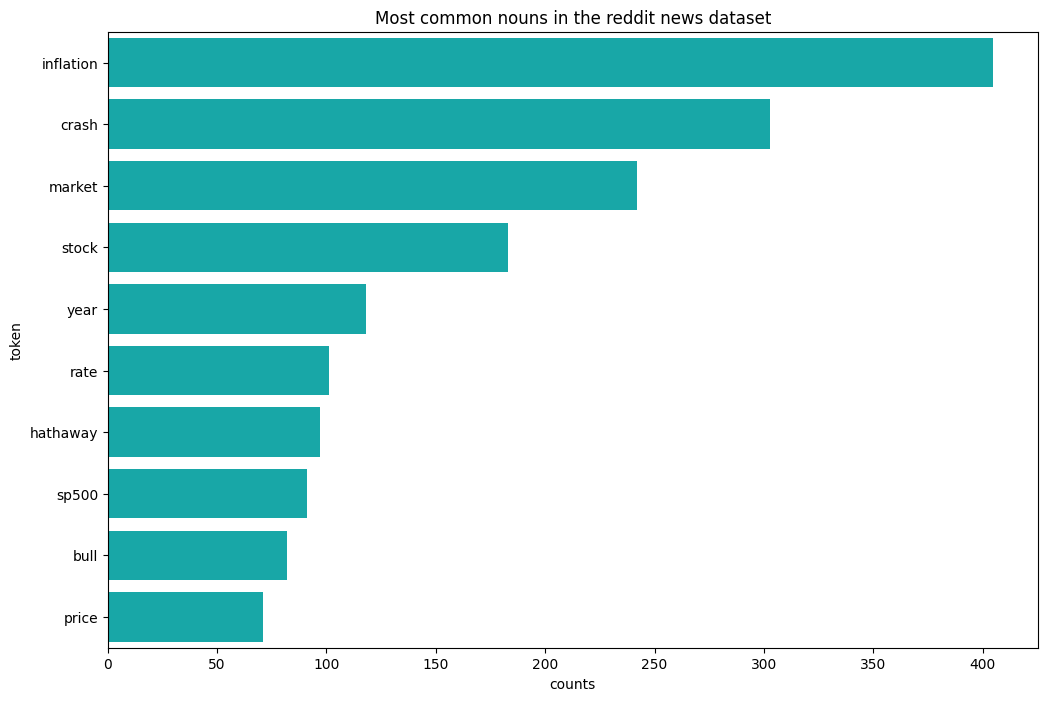

In [37]:
#Let's see the most common nouns

sns.barplot(data=pos_df_counts[pos_df_counts['pos_tag']=='NOUN'].head(10), x='counts', y='token', color=default_plot_colour)
plt.title('Most common nouns in the reddit news dataset')

Text(0.5, 1.0, 'Most common proper nouns in the reddit news dataset')

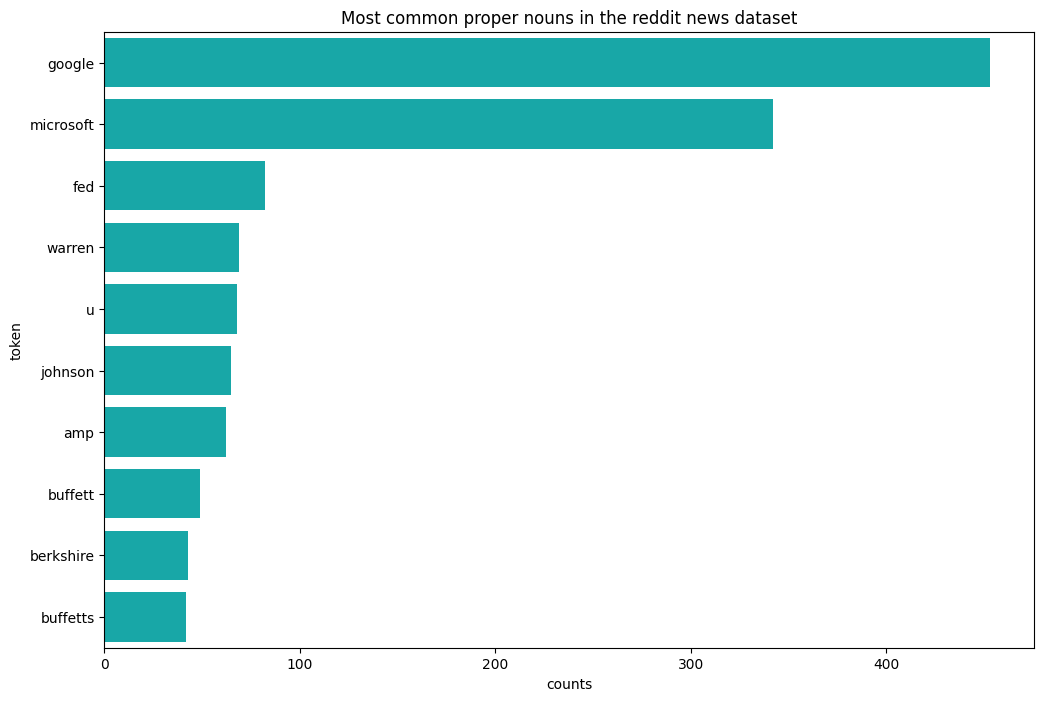

In [38]:
#Let's see the most common proper nouns

sns.barplot(data=pos_df_counts[pos_df_counts['pos_tag']=='PROPN'].head(10), x='counts', y='token', color=default_plot_colour)
plt.title('Most common proper nouns in the reddit news dataset')

## Named Entities Recognition

*To move beyond basic grammatical tagging, I am implementing Named Entity Recognition (NER). This allows for the automated extraction of structured information, specifically identifying Organizations (ORG), Locations (GPE), and Financial Values, providing a clearer mapping of the key market actors and geographic drivers within the dataset.*

In [39]:
ner_df = pd.DataFrame(columns=['token', 'ner_tag'])

In [40]:
for token in spacy_doc.ents:
    ner_df = pd.concat([ner_df,
                        pd.DataFrame.from_records([{'token':token.text, 'ner_tag':token.label_}])], ignore_index=True)

In [43]:
ner_df.head(10)

,token,ner_tag
0,fed,ORG
1,fed,ORG
2,25b,CARDINAL
3,19,CARDINAL
4,1986,DATE
5,uk netherlands,GPE
6,2008,DATE
7,british dutch depositor,ORG
8,india,GPE
9,102,CARDINAL


In [44]:
#token frequency count

ner_df_counts = ner_df.groupby(['token', 'ner_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)

ner_df_counts.head(10)

,token,ner_tag,counts
898,microsoft,ORG,194
668,fed,ORG,90
714,google,ORG,78
715,google,PRODUCT,65
1157,warren buffett,PERSON,29
806,johnson,PERSON,28
676,first,ORDINAL,26
517,annual,DATE,23
598,china,GPE,23
165,2,CARDINAL,20


In [45]:
#frequencies of ner tags

ner_tag_counts = ner_df_counts.groupby(['ner_tag'])['token'].count().sort_values(ascending=False)

ner_tag_counts.head(15)

ner_tag
CARDINAL    298
DATE        269
ORG         198
PERSON      181
GPE          79
MONEY        35
NORP         33
PRODUCT      29
ORDINAL      16
QUANTITY     15
PERCENT      12
LOC           8
TIME          7
FAC           4
LAW           1
Name: token, dtype: int64

Text(0.5, 1.0, 'Most common person names in the reddit news dataset')

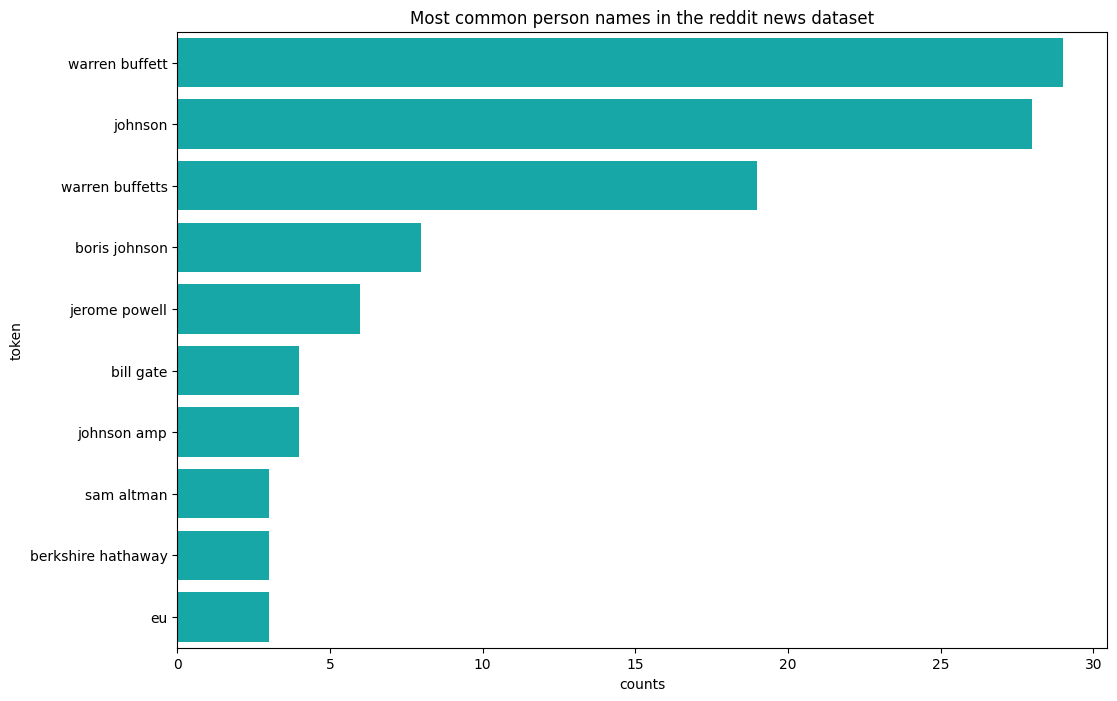

In [46]:
#Let's see the most common persons

sns.barplot(data=ner_df_counts[ner_df_counts['ner_tag']=='PERSON'].head(10), x='counts', y='token', color=default_plot_colour)
plt.title('Most common person names in the reddit news dataset')

Text(0.5, 1.0, 'Most common dates in the reddit news dataset')

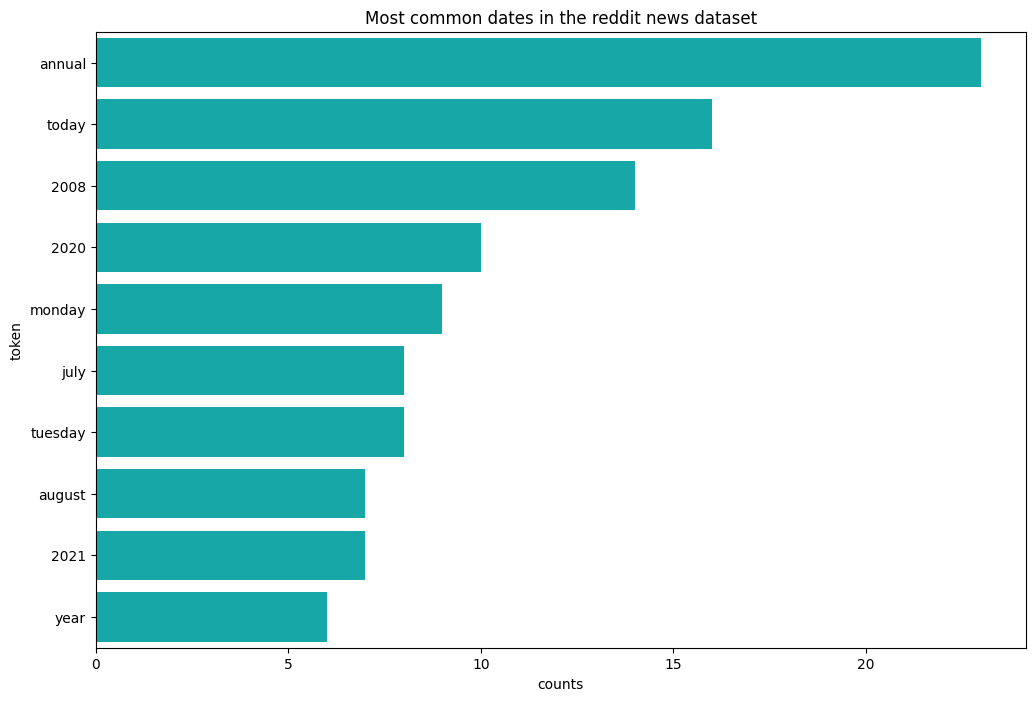

In [47]:
#Let's see the most common dates

sns.barplot(data=ner_df_counts[ner_df_counts['ner_tag']=='DATE'].head(10), x='counts', y='token', color=default_plot_colour)
plt.title('Most common dates in the reddit news dataset')

Text(0.5, 1.0, 'Most common organizations in the reddit news dataset')

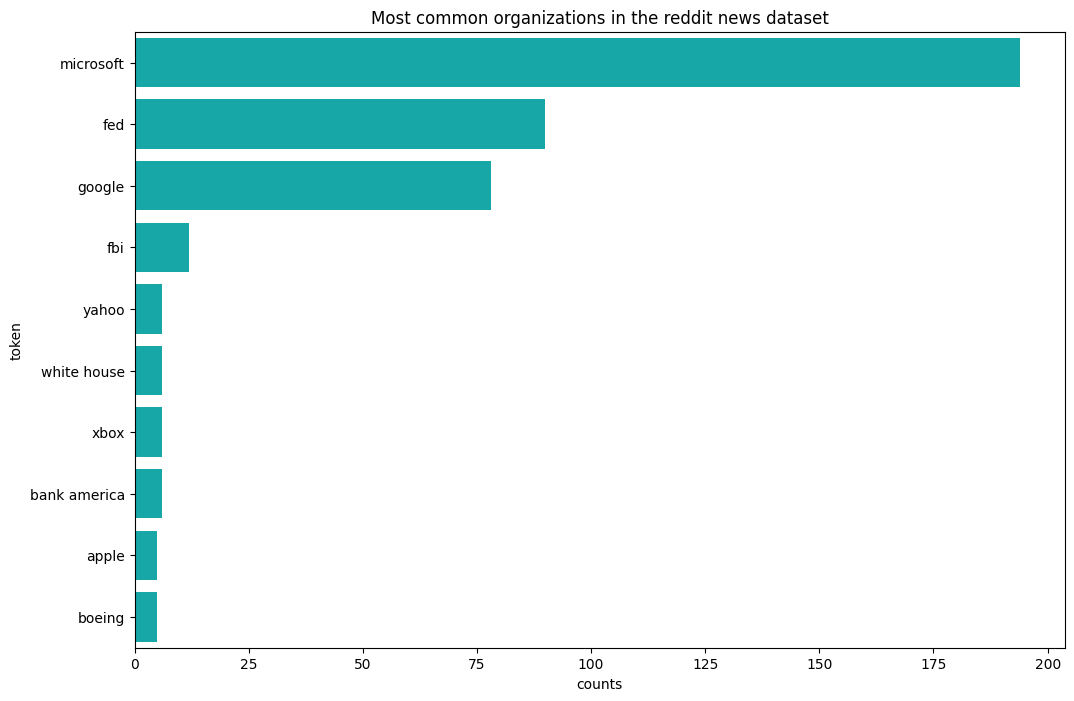

In [48]:
#Let's see the most common organizations

sns.barplot(data=ner_df_counts[ner_df_counts['ner_tag']=='ORG'].head(10), x='counts', y='token', color=default_plot_colour)
plt.title('Most common organizations in the reddit news dataset')

Text(0.5, 1.0, 'Most common geopolitical entities in the reddit news dataset')

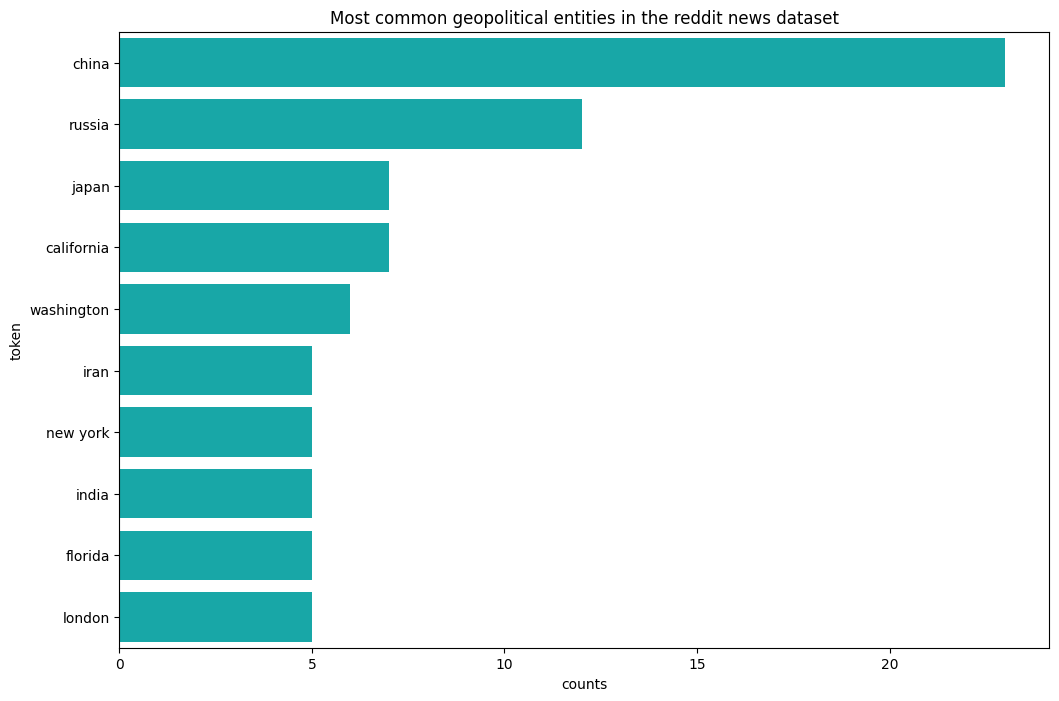

In [49]:
#Let's see the most common Geopolitical Entities

sns.barplot(data=ner_df_counts[ner_df_counts['ner_tag']=='GPE'].head(10), x='counts', y='token', color=default_plot_colour)
plt.title('Most common geopolitical entities in the reddit news dataset')

[Text(0.5, 1.0, 'Most Common Entities in Reddit News')]

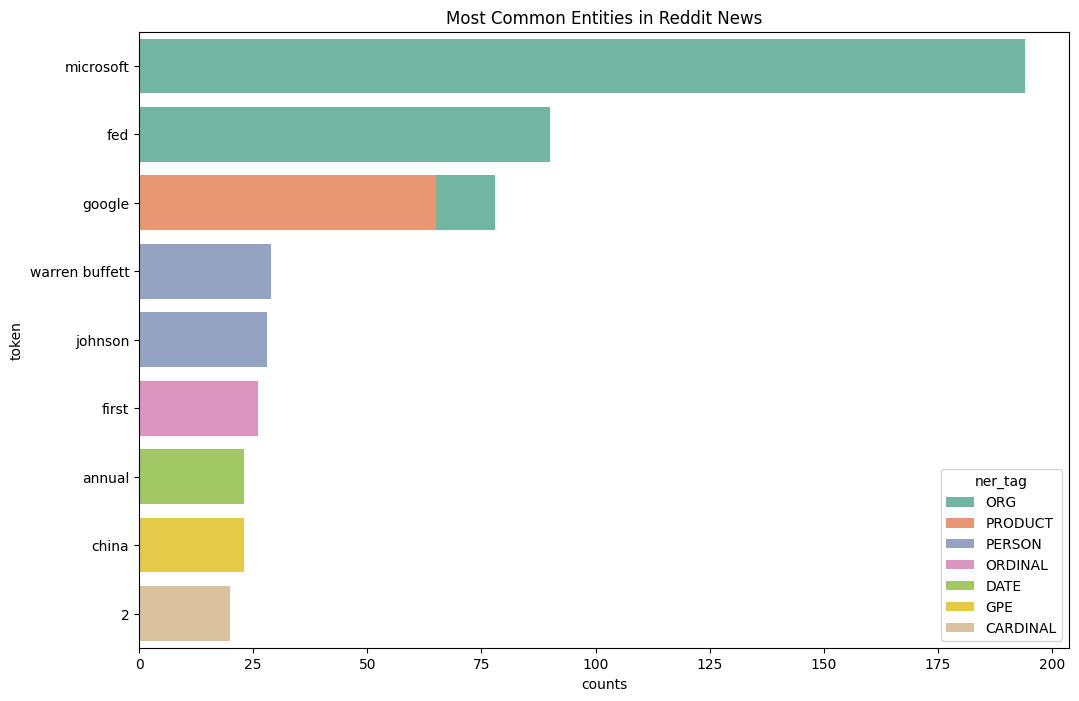

In [50]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = 'Set2',
    data = ner_df_counts[0:10],
    orient = 'h',
    dodge=False
) \
.set(title='Most Common Entities in Reddit News')

## Sentiment Analysis

In [51]:
news_prep.head()

,date,news,clean,no_stopwords,tokens,lemmatize
0,2009-05-09,SP500 Elliott Wave Update: Competiting Interpr...,sp500 elliott wave update competiting interpre...,sp500 elliott wave update competiting interpre...,"[sp500, elliott, wave, update, competiting, in...","[sp500, elliott, wave, update, competiting, in..."
1,2009-06-04,The Gold Bull Market and the Fed it Rode In On,the gold bull market and the fed it rode in on,gold bull market fed rode,"[gold, bull, market, fed, rode]","[gold, bull, market, fed, rode]"
2,2009-06-25,What inflation ? Rates fall as Fed sells $25B...,what inflation rates fall as fed sells 25b i...,inflation rates fall fed sells 25b bonds,"[inflation, rates, fall, fed, sells, 25b, bonds]","[inflation, rate, fall, fed, sell, 25b, bond]"
3,2009-10-10,T-Mobile Sidekick Disaster: Microsoft and T-Mo...,tmobile sidekick disaster microsoft and tmobil...,tmobile sidekick disaster microsoft tmobile lo...,"[tmobile, sidekick, disaster, microsoft, tmobi...","[tmobile, sidekick, disaster, microsoft, tmobi..."
4,2010-05-10,Correlation Math Signals Bull Market; Oil\r\nS...,correlation math signals bull market oil\r\nst...,correlation math signals bull market oil stock...,"[correlation, math, signals, bull, market, oil...","[correlation, math, signal, bull, market, oil,..."


For the sentiment analysis, I will use the cleaned dataset ('clean' column) that is entirely in lowercase and free of punctuation. This preprocessing step keeps the meaning and contextual relationships between words, allowing the classifiers to assign more accurate sentiment scores to each news article.

In [52]:
reddit_news = news_prep[['date','clean']]

reddit_news.head()

,date,clean
0,2009-05-09,sp500 elliott wave update competiting interpre...
1,2009-06-04,the gold bull market and the fed it rode in on
2,2009-06-25,what inflation rates fall as fed sells 25b i...
3,2009-10-10,tmobile sidekick disaster microsoft and tmobil...
4,2010-05-10,correlation math signals bull market oil\r\nst...


### Pre-trained transformers

In [53]:
print(f"Is GPU available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Is GPU available? True
GPU Name: NVIDIA GeForce GTX 1650


In [54]:
transformer_model = pipeline('sentiment-analysis', model='ProsusAI/finbert')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [55]:
transformer_labels = []
for news in reddit_news['clean'].values:
    sent_list = transformer_model(news)
    sent_label = sent_list[0]['label']
    transformer_labels.append(sent_label)
reddit_news['transformer_sentiment_label'] = transformer_labels

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
C:\Users\mihai\AppData\Local\Temp\ipykernel_1076\57740854.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reddit_news['transformer_sentiment_label'] = transformer_labels


Text(0.5, 1.0, 'FinBert transformer labels for the reddit dataset')

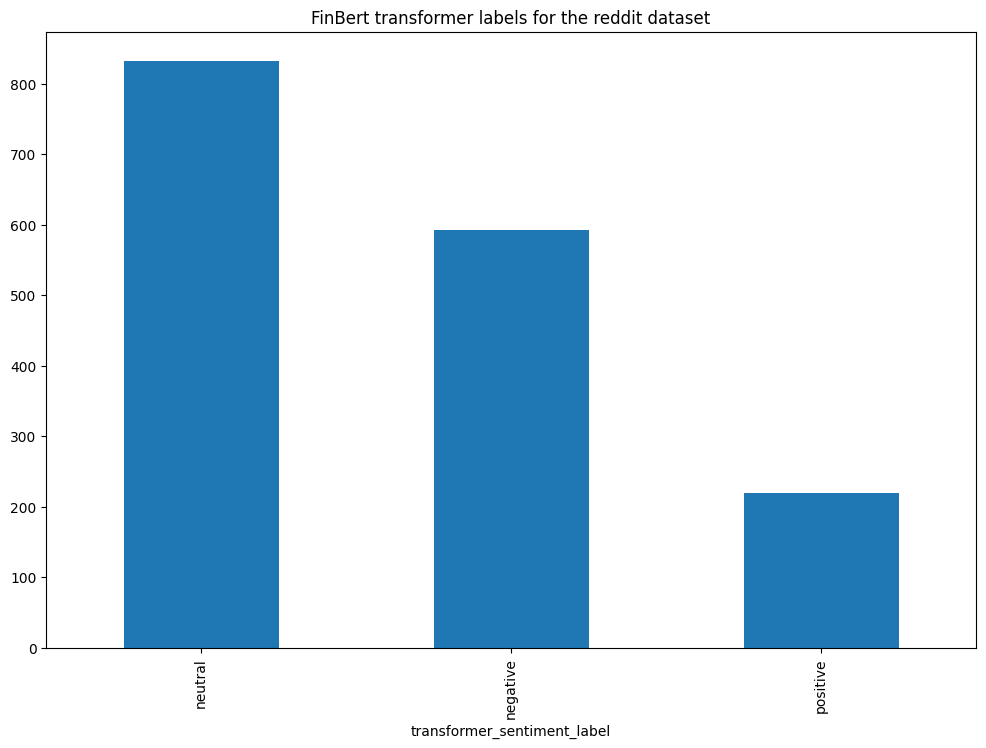

In [56]:
reddit_news['transformer_sentiment_label'].value_counts().plot.bar()
plt.title('FinBert transformer labels for the reddit dataset')

In [57]:
reddit_news['transformer_score'] = reddit_news['transformer_sentiment_label'].map({'neutral':0, 'negative':-1, 'positive':1})

C:\Users\mihai\AppData\Local\Temp\ipykernel_1076\4237318370.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reddit_news['transformer_score'] = reddit_news['transformer_sentiment_label'].map({'neutral':0, 'negative':-1, 'positive':1})


In [58]:
reddit_news.head()

,date,clean,transformer_sentiment_label,transformer_score
0,2009-05-09,sp500 elliott wave update competiting interpre...,neutral,0
1,2009-06-04,the gold bull market and the fed it rode in on,neutral,0
2,2009-06-25,what inflation rates fall as fed sells 25b i...,negative,-1
3,2009-10-10,tmobile sidekick disaster microsoft and tmobil...,negative,-1
4,2010-05-10,correlation math signals bull market oil\r\nst...,positive,1


In [ ]:
reddit_news.to_csv('../datasets/Data_final_news_reddit.csv', index=False)